# **Problema 1: Integración analítica de flujos**

Halle las trayectorias, las líneas de corriente las trazas de una partícula ubicada en $(x_0, y_0)$ a $t = 0$, para los siguientes campos de velocidades bidimensionales:

(i) Una corriente uniforme constante $U$ superpuesta a otra corriente uniforme ortogonal a la primera. La velocidad $U'$ de la segunda corriente está modulada en forma armónica en el tiempo con período $\tau$.

(ii) Un flujo con campo de velocidad dado por
$$ \mathbf{u}(x, y, t) =  \frac{\alpha x}{1+\beta t}\mathbf{\hat{x}} + c\mathbf{\hat{y}} $$

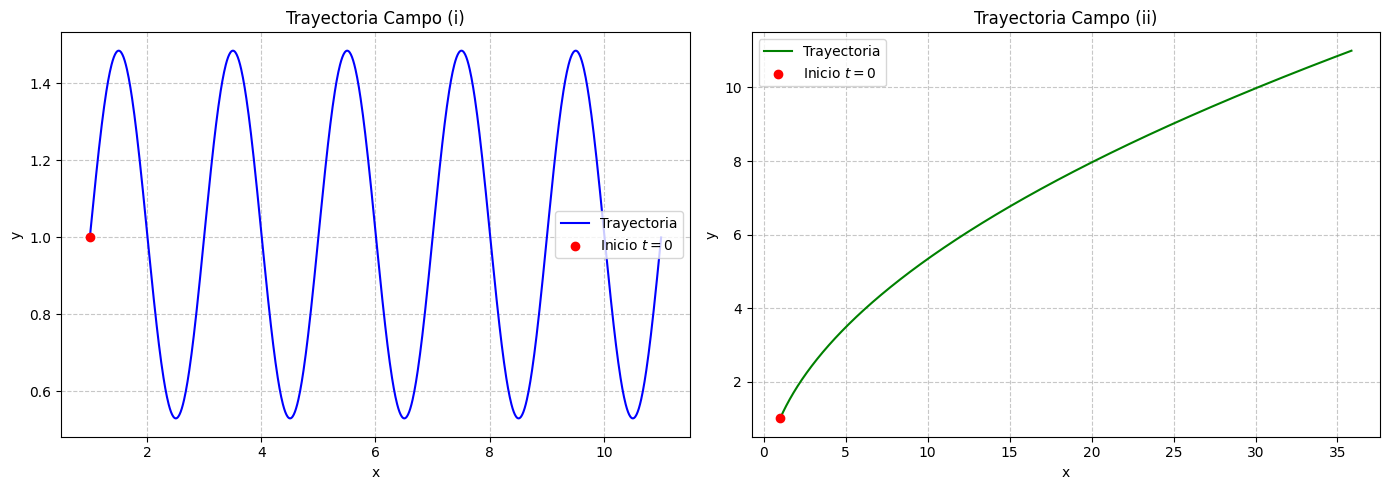

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def esquema(X, u, t, dt):
    """
    Calcula X(t+dt) a partir de X(t) y el campo de velocidades usando Euler explícito.
    """
    return X + u(X, t) * dt

def trayectoria(X0, u, N, dt):
    """
    Calcula numéricamente la solución a dX/dt = u(X,t)
    """
    d = X0.shape[0]
    ts = np.arange(0, N+1)*dt
    Xs = np.zeros((N+1, d))
    Xs[0] = X0
    for j in range(N):
        Xs[j+1] = esquema(Xs[j], u, ts[j], dt)
    return ts, Xs
    # Parámetros físicos (puedes modificarlos para explorar diferentes regímenes)
U_const = 1.0
U_amp = 1.5
tau = 2.0

alpha = 1.0
beta = 0.5
c = 1.0

def campo_1(X, t):
    """Campo de velocidades (i)"""
    u_x = U_const
    u_y = U_amp * np.cos(2 * np.pi * t / tau)
    return np.array([u_x, u_y])

def campo_2(X, t):
    """Campo de velocidades (ii)"""
    x = X[0]
    # Se evita división por cero si beta*t != -1
    u_x = (alpha * x) / (1 + beta * t)
    u_y = c
    return np.array([u_x, u_y])
    # Parámetros de integración
dt = 0.01
N = 1000 # Integramos hasta t = N*dt = 10 segundos
X0 = np.array([1.0, 1.0]) # Condición inicial (x0, y0) a t=0

# Calcular trayectorias
ts_1, Xs_1 = trayectoria(X0, campo_1, N, dt)
ts_2, Xs_2 = trayectoria(X0, campo_2, N, dt)

# Extraer coordenadas para graficar
x1, y1 = Xs_1[:, 0], Xs_1[:, 1]
x2, y2 = Xs_2[:, 0], Xs_2[:, 1]

# Configuración del gráfico
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico Campo (i)
ax[0].plot(x1, y1, color='blue', label='Trayectoria')
ax[0].scatter([X0[0]], [X0[1]], color='red', zorder=5, label=f'Inicio $t=0$')
ax[0].set_title('Trayectoria Campo (i)')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[0].grid(True, linestyle='--', alpha=0.7)
ax[0].legend()

# Gráfico Campo (ii)
ax[1].plot(x2, y2, color='green', label='Trayectoria')
ax[1].scatter([X0[0]], [X0[1]], color='red', zorder=5, label=f'Inicio $t=0$')
ax[1].set_title('Trayectoria Campo (ii)')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
ax[1].grid(True, linestyle='--', alpha=0.7)
ax[1].legend()

plt.tight_layout()
plt.show()